# 30-Day Readmission Risk — Feature Engineering

**Project:** Patient Readmission Risk Model  
**Input:** `data/interim/labelled_encounters.csv`  
**Output:** `data/processed/feature_matrix.csv`  
**Author:** Ibrahim A. Mikail
**Date:** June 2026

---

## Objective

Transform the labelled encounter dataset into a rich feature matrix by joining clinical data from five Synthea tables.

Every feature is:
1. **Clinically justified** — based on published readmission literature
2. **Available at discharge** — no target leakage
3. **Documented** — with its clinical rationale

## Feature Sources

| Source | Features | Clinical rationale |
|--------|----------|-------------------|
| Encounters | LOS, acuity, prior admissions, ED visits | LACE index components |
| Conditions | Charlson score, disease flags | Comorbidity burden |
| Medications | Drug count, high-risk flags | Polypharmacy risk |
| Patients | Age, gender | Demographic risk factors |

---

## Anti-leakage Checklist

Before adding any feature we ask:
> *"Would a clinician know this value at the moment of discharge?"*

If no → feature is excluded (target leakage).
If yes → feature is included.

## 1. Setup and Load Data

In [1]:
# imports, load data, and normalise all timestamps

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

INTERIM_PATH   = "../data/interim"
RAW_PATH       = "../data/raw/output/csv"
PROCESSED_PATH = "../data/processed"

def strip_tz(df, cols):
    """Strip timezone from datetime columns — makes all dates naive UTC."""
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True).dt.tz_localize(None)
    return df

# Load labelled encounters
encounters_labelled = pd.read_csv(
    f"{INTERIM_PATH}/labelled_encounters.csv"
)
encounters_labelled = strip_tz(
    encounters_labelled,
    ['START', 'STOP', 'NEXT_ADMISSION']
)

# Load all raw tables
patients = pd.read_csv(f"{RAW_PATH}/patients.csv")
strip_tz(patients, ['BIRTHDATE', 'DEATHDATE'])

all_encounters = pd.read_csv(f"{RAW_PATH}/encounters.csv")
strip_tz(all_encounters, ['START', 'STOP'])

conditions = pd.read_csv(f"{RAW_PATH}/conditions.csv")
strip_tz(conditions, ['START', 'STOP'])

medications = pd.read_csv(f"{RAW_PATH}/medications.csv")
strip_tz(medications, ['START', 'STOP'])

observations = pd.read_csv(f"{RAW_PATH}/observations.csv")

# Verify all START columns are timezone-naive
print("=== TIMEZONE CHECK ===")
for name, df in [
    ('encounters_labelled', encounters_labelled),
    ('all_encounters', all_encounters),
    ('conditions', conditions),
    ('medications', medications),
]:
    dtype = df['START'].dtype
    print(f"  {name:<25} START dtype: {dtype}")

print("\n=== DATA LOADED ===")
print(f"Labelled encounters:  {len(encounters_labelled):,}")
print(f"All encounters:       {len(all_encounters):,}")
print(f"Patients:             {len(patients):,}")
print(f"Conditions:           {len(conditions):,}")
print(f"Medications:          {len(medications):,}")
print(f"Observations:         {len(observations):,}")

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

=== TIMEZONE CHECK ===
  encounters_labelled       START dtype: datetime64[us]
  all_encounters            START dtype: datetime64[us]
  conditions                START dtype: datetime64[us]
  medications               START dtype: datetime64[us]

=== DATA LOADED ===
Labelled encounters:  3,773
All encounters:       653,828
Patients:             11,381
Conditions:           405,862
Medications:          535,809
Observations:         8,270,961


## 2. Encounter-Level Features

Features derived directly from the current admission and from 
the patient's prior encounter history.

### Anti-leakage check 
All features below are knowable at the point of discharge:
- LOS is known when the patient leaves
- Prior admissions happened before this admission
- Admission timing is known throughout the stay

In [2]:
# Encounter-level features

# Start with our labelled cohort
features = encounters_labelled[[
    'Id_x', 'PATIENT', 'START', 'STOP',
    'ENCOUNTERCLASS', 'READMITTED_30D',
    'LOS_DAYS'
]].copy()

# --- Feature 1: Length of Stay (log-transformed) ---
# Log transform reduces right skew from outlier long stays
# log1p used because log(0) is undefined — adds 1 before logging
features['los_days'] = features['LOS_DAYS']
features['los_days_log'] = np.log1p(features['LOS_DAYS'])

# --- Feature 2: Admission month (seasonality) ---
# Respiratory readmissions peak in winter months
features['admission_month'] = features['START'].dt.month

# --- Feature 3: Admission day of week ---
# Weekend admissions often have less specialist cover
features['admission_dow'] = features['START'].dt.dayofweek

# --- Feature 4: Is emergency admission ---
# Acuity — the A in LACE
# We check if patient had an ED visit on the same day as admission
ed_visits = all_encounters[
    all_encounters['ENCOUNTERCLASS'] == 'emergency'
][['PATIENT', 'START']].copy()
ed_visits['START'] = pd.to_datetime(ed_visits['START'])
ed_visits['ed_date'] = ed_visits['START'].dt.date

features['admission_date'] = features['START'].dt.date
ed_dates = set(
    zip(ed_visits['PATIENT'], ed_visits['ed_date'])
)
features['is_emergency'] = features.apply(
    lambda r: 1 if (r['PATIENT'], r['admission_date']) 
    in ed_dates else 0, axis=1
)

print("=== ENCOUNTER FEATURES (current admission) ===")
print(f"LOS stats:")
print(features['los_days'].describe().round(2))
print(f"\nEmergency admissions: "
      f"{features['is_emergency'].sum():,} "
      f"({features['is_emergency'].mean()*100:.1f}%)")
print(f"\nAdmission month distribution:")
print(features['admission_month'].value_counts().sort_index())

=== ENCOUNTER FEATURES (current admission) ===
LOS stats:
count    3773.00
mean        4.15
std         5.09
min         1.00
25%         1.00
50%         2.00
75%         5.00
max        73.00
Name: los_days, dtype: float64

Emergency admissions: 384 (10.2%)

Admission month distribution:
admission_month
1     296
2     302
3     311
4     344
5     318
6     326
7     329
8     305
9     310
10    301
11    312
12    319
Name: count, dtype: int64


## 3. Prior Admission History Features

These are the strongest predictors of readmission — 
published literatures consistently ranks prior admissions 
as the #1 predictor.

**Key concept — temporal integrity:**  
For each admission, we only look at encounters that occurred 
*before* the current admission start date. Looking at future 
encounters would constitute target leakage.

This requires a self-join on the encounters table — joining 
each encounter against all *prior* encounters for the same patient.

In [3]:
# Prior admission history features

# Working with inpatient encounters only for prior admission counts
inpatient_all = all_encounters[
    all_encounters['ENCOUNTERCLASS'] == 'inpatient'
].copy()
inpatient_all['START'] = pd.to_datetime(inpatient_all['START'])
inpatient_all['STOP']  = pd.to_datetime(inpatient_all['STOP'])

# ED encounters for prior ED visit count
ed_all = all_encounters[
    all_encounters['ENCOUNTERCLASS'] == 'emergency'
].copy()
ed_all['START'] = pd.to_datetime(ed_all['START'])

# For each labelled encounter calculate prior history
prior_features = []

for _, row in features.iterrows():
    patient_id   = row['PATIENT']
    admit_date   = row['START']

    # All prior inpatient encounters for this patient
    prior_inpatient = inpatient_all[
        (inpatient_all['PATIENT'] == patient_id) &
        (inpatient_all['START'] < admit_date)
    ]

    # All prior ED encounters for this patient
    prior_ed = ed_all[
        (ed_all['PATIENT'] == patient_id) &
        (ed_all['START'] < admit_date)
    ]

    # 6-month and 12-month windows
    cutoff_6m  = admit_date - pd.DateOffset(months=6)
    cutoff_12m = admit_date - pd.DateOffset(months=12)

    n_prior_6m  = (prior_inpatient['START'] >= cutoff_6m).sum()
    n_prior_12m = (prior_inpatient['START'] >= cutoff_12m).sum()
    n_ed_6m     = (prior_ed['START'] >= cutoff_6m).sum()

    # Days since last admission
    if len(prior_inpatient) > 0:
        last_admit = prior_inpatient['START'].max()
        days_since = (admit_date - last_admit).days
    else:
        days_since = 999  # No prior admission — large sentinel value

    prior_features.append({
        'Id_x': row['Id_x'],
        'n_admissions_prior_6m':     n_prior_6m,
        'n_admissions_prior_12m':    n_prior_12m,
        'n_ed_visits_prior_6m':      n_ed_6m,
        'days_since_last_admission': days_since,
        'has_prior_admission':       1 if len(prior_inpatient) > 0 else 0
    })

prior_df = pd.DataFrame(prior_features)
features = features.merge(prior_df, on='Id_x', how='left')

print("=== PRIOR ADMISSION FEATURES ===")
print(f"\nPrior 6-month admissions:")
print(features['n_admissions_prior_6m'].value_counts()
      .sort_index().head(8))
print(f"\nPatients with no prior admission: "
      f"{(features['has_prior_admission']==0).sum():,} "
      f"({(features['has_prior_admission']==0).mean()*100:.1f}%)")
print(f"\nMean prior 6m admissions: "
      f"{features['n_admissions_prior_6m'].mean():.2f}")
print(f"Mean prior ED visits 6m:  "
      f"{features['n_ed_visits_prior_6m'].mean():.2f}")

=== PRIOR ADMISSION FEATURES ===

Prior 6-month admissions:
n_admissions_prior_6m
0    2905
1     449
2     199
3     103
4     105
5      12
Name: count, dtype: int64

Patients with no prior admission: 1,671 (44.3%)

Mean prior 6m admissions: 0.43
Mean prior ED visits 6m:  0.34


## 4. Comorbidity Features — Charlson Index

The Charlson Comorbidity Index (CCI) assigns weighted scores to 17 chronic conditions based on their associated mortality risk. A higher score indicates greater disease burden and predicts higher readmission risk.

**Charlson condition weights:**

| Score | Conditions |
|-------|-----------|
| 6 | AIDS, Metastatic solid tumour |
| 3 | Moderate/severe liver disease |
| 2 | Hemiplegia, CKD, diabetes with complications, cancer |
| 1 | MI, heart failure, PVD, dementia, COPD, diabetes, |
|   | connective tissue disease, peptic ulcer, mild liver disease |

We map Synthea condition descriptions to these categories
using keyword matching — a pragmatic approach when exact
ICD codes are unavailable.

### Anti-leakage check
We only include conditions that were **active at or before**
the admission date — not conditions diagnosed after discharge.

In [4]:
# Charlson Comorbidity Index and disease flags

# Charlson condition keyword mapping
# Keys are keywords to search in condition DESCRIPTION
# Values are [charlson_points, feature_flag_name]
CHARLSON_MAP = {
    # Score 6
    'human immunodeficiency':       (6, 'has_aids'),
    'hiv':                          (6, 'has_aids'),
    'metastatic':                   (6, 'has_cancer'),

    # Score 3
    'liver failure':                (3, 'has_liver_severe'),
    'esophageal varices':           (3, 'has_liver_severe'),

    # Score 2
    'hemiplegia':                   (2, 'has_hemiplegia'),
    'paraplegia':                   (2, 'has_hemiplegia'),
    'chronic kidney disease stage 4':(2,'has_ckd'),
    'chronic kidney disease stage 5':(2,'has_ckd'),
    'end stage renal':              (2, 'has_ckd'),
    'diabetes mellitus type 2 with':(2, 'has_diabetes_complex'),
    'malignant':                    (2, 'has_cancer'),
    'carcinoma':                    (2, 'has_cancer'),
    'lymphoma':                     (2, 'has_cancer'),
    'leukemia':                     (2, 'has_cancer'),

    # Score 1
    'myocardial infarction':        (1, 'has_mi'),
    'heart failure':                (1, 'has_heart_failure'),
    'peripheral vascular':          (1, 'has_pvd'),
    'cerebrovascular':              (1, 'has_cerebrovascular'),
    'dementia':                     (1, 'has_dementia'),
    'chronic obstructive':          (1, 'has_copd'),
    'diabetes mellitus type 2':     (1, 'has_diabetes'),
    'diabetes mellitus type 1':     (1, 'has_diabetes'),
    'rheumatoid arthritis':         (1, 'has_connective'),
    'lupus':                        (1, 'has_connective'),
    'peptic ulcer':                 (1, 'has_peptic_ulcer'),
    'chronic kidney disease':       (1, 'has_ckd'),
}

# All disease flags we'll track
DISEASE_FLAGS = list(set([v[1] for v in CHARLSON_MAP.values()]))

def compute_charlson_features(patient_id, admit_date, conditions_df):
    """
    Compute Charlson score and disease flags for one patient
    at the time of a specific admission.
    
    Only includes conditions active at or before admission date.
    """
    # Get conditions for this patient before/at admission
    pt_conditions = conditions_df[
        (conditions_df['PATIENT'] == patient_id) &
        (conditions_df['START'] <= admit_date)
    ]['DESCRIPTION'].str.lower().tolist()

    charlson_score = 0
    flags = {flag: 0 for flag in DISEASE_FLAGS}
    n_conditions = len(pt_conditions)

    # Score each condition
    scored_categories = set()  # avoid double-counting same category
    for condition_text in pt_conditions:
        for keyword, (points, flag_name) in CHARLSON_MAP.items():
            if keyword.lower() in condition_text:
                flags[flag_name] = 1
                # Only add points once per category
                if flag_name not in scored_categories:
                    charlson_score += points
                    scored_categories.add(flag_name)
                break

    return charlson_score, flags, n_conditions


# Apply to all encounters

charlson_results = []
for _, row in features.iterrows():
    score, flags, n_cond = compute_charlson_features(
        row['PATIENT'],
        row['START'],
        conditions
    )
    result = {'Id_x': row['Id_x'], 'charlson_score': score,
              'n_active_conditions': n_cond}
    result.update(flags)
    charlson_results.append(result)

charlson_df = pd.DataFrame(charlson_results)
features = features.merge(charlson_df, on='Id_x', how='left')

print("=== CHARLSON INDEX RESULTS ===")
print(f"\nCharlson score distribution:")
print(features['charlson_score'].value_counts()
      .sort_index().head(10))
print(f"\nMean Charlson score: {features['charlson_score'].mean():.2f}")
print(f"Max Charlson score:  {features['charlson_score'].max()}")

print(f"\nDisease flag prevalence:")
flag_cols = [c for c in features.columns if c.startswith('has_')]
for col in sorted(flag_cols):
    pct = features[col].mean() * 100
    if pct > 0:
        print(f"  {col:<30} {pct:.1f}%")

=== CHARLSON INDEX RESULTS ===

Charlson score distribution:
charlson_score
0    2077
1     734
2     664
3     208
4      72
5      11
6       4
7       1
9       2
Name: count, dtype: int64

Mean Charlson score: 0.82
Max Charlson score:  9

Disease flag prevalence:
  has_aids                       0.1%
  has_cancer                     19.1%
  has_cerebrovascular            0.2%
  has_ckd                        12.6%
  has_connective                 0.2%
  has_copd                       1.5%
  has_diabetes                   11.3%
  has_heart_failure              7.1%
  has_mi                         9.4%
  has_prior_admission            55.7%


## 5. Medication Features

Polypharmacy : being prescribed many medications simultaneously,
is a strong readmission predictor. Complex medication regimens 
are harder to manage post-discharge, increasing the risk of 
errors, interactions, and non-adherence.

**High-risk drug classes** are medications that require careful 
monitoring and are frequently implicated in readmissions:
- **Insulin** : hypoglycaemia risk
- **Anticoagulants** : bleeding or clotting risk  
- **Diuretics** : electrolyte imbalance, dehydration
- **ACE inhibitors** : renal function monitoring needed

### Anti-leakage check 
We include only medications prescribed at or before discharge.

In [5]:
# Medication features

HIGH_RISK_DRUGS = {
    'insulin':          'has_insulin',
    'warfarin':         'has_anticoagulant',
    'heparin':          'has_anticoagulant',
    'apixaban':         'has_anticoagulant',
    'rivaroxaban':      'has_anticoagulant',
    'furosemide':       'has_diuretic',
    'hydrochlorothiazide': 'has_diuretic',
    'spironolactone':   'has_diuretic',
    'lisinopril':       'has_ace_inhibitor',
    'enalapril':        'has_ace_inhibitor',
    'ramipril':         'has_ace_inhibitor',
    'metformin':        'has_metformin',
    'digoxin':          'has_digoxin',
}

def compute_medication_features(patient_id, admit_date,
                                stop_date, medications_df):
    """
    Count medications active during this admission.
    Includes medications started before or during admission,
    still active at discharge.
    """
    pt_meds = medications_df[
        (medications_df['PATIENT'] == patient_id) &
        (medications_df['START'] <= stop_date)
    ]['DESCRIPTION'].str.lower().tolist()

    n_meds = len(pt_meds)
    drug_flags = {v: 0 for v in HIGH_RISK_DRUGS.values()}

    for med_text in pt_meds:
        for keyword, flag_name in HIGH_RISK_DRUGS.items():
            if keyword.lower() in med_text:
                drug_flags[flag_name] = 1
                break

    return n_meds, drug_flags

print("Computing medication features...")

med_results = []
for _, row in features.iterrows():
    n_meds, drug_flags = compute_medication_features(
        row['PATIENT'],
        row['START'],
        row['STOP'],
        medications
    )
    result = {'Id_x': row['Id_x'], 'n_medications': n_meds}
    result.update(drug_flags)
    med_results.append(result)

med_df = pd.DataFrame(med_results)
features = features.merge(med_df, on='Id_x', how='left')

print("=== MEDICATION FEATURES ===")
print(f"\nMedication count distribution:")
print(features['n_medications'].describe().round(1))
print(f"\nHigh-risk drug prevalence:")
drug_cols = [c for c in features.columns
             if c.startswith('has_') and
             c not in flag_cols]
for col in sorted(drug_cols):
    pct = features[col].mean() * 100
    if pct > 0:
        print(f"  {col:<30} {pct:.1f}%")
        
# Cap medication count at 99th percentile to reduce outlier influence
# Then flag extreme polypharmacy separately
p99 = features['n_medications'].quantile(0.99)
features['n_medications_capped'] = features['n_medications'].clip(upper=p99)
features['is_high_polypharmacy'] = (features['n_medications'] > 10).astype(int)

print(f"\n99th percentile medication count: {p99:.0f}")
print(f"After capping - max: {features['n_medications_capped'].max():.0f}")
print(f"High polypharmacy (>10 meds): "
      f"{features['is_high_polypharmacy'].mean()*100:.1f}%")

Computing medication features...
=== MEDICATION FEATURES ===

Medication count distribution:
count    3773.0
mean       39.5
std        94.7
min         0.0
25%         1.0
50%        12.0
75%        38.0
max      1217.0
Name: n_medications, dtype: float64

High-risk drug prevalence:
  has_ace_inhibitor              21.9%
  has_anticoagulant              22.1%
  has_digoxin                    0.9%
  has_diuretic                   20.6%
  has_insulin                    10.8%
  has_metformin                  4.8%

99th percentile medication count: 520
After capping - max: 520
High polypharmacy (>10 meds): 51.4%


## 6. Patient Demographic Features

Age and gender are included as demographic risk factors,
consistent with published readmission literature.

**Age** is calculated at the time of admission — not current age.
This is important for historical encounters dating back decades.

**Gender** is binary-encoded (male=1, female=0).
We noted in our exploratory data analysis notebook that males readmit at 11.6% vs 5.2% for females.
We include it as a feature but will evaluate model fairness across both groups in the evaluation phase.

In [7]:
# Patient demographic features

patient_features = patients[[
    'Id', 'BIRTHDATE', 'GENDER', 'RACE', 'INCOME'
]].copy()

# Merge onto features
features = features.merge(
    patient_features,
    left_on='PATIENT',
    right_on='Id',
    how='left',
    suffixes=('', '_patient')
)

# Age at admission. not current age
features['BIRTHDATE'] = pd.to_datetime(features['BIRTHDATE'])
features['age_at_admission'] = (
    (features['START'] - features['BIRTHDATE']).dt.days / 365.25
).round(1)

# Filter to adults only as paediatric readmission is a different model
features = features[features['age_at_admission'] >= 18].copy()
print(f"After adult-only filter: {len(features):,} encounters")
print(f"Removed {3773 - len(features)} paediatric encounters")

# Binary encode gender
features['gender_male'] = (features['GENDER'] == 'M').astype(int)

# Income — keep as continuous socioeconomic proxy
features['income'] = features['INCOME']

print("=== DEMOGRAPHIC FEATURES ===")
print(f"\nAge at admission:")
print(features['age_at_admission'].describe().round(1))
print(f"\nGender distribution:")
print(features['gender_male'].value_counts())
print(f"\nIncome distribution:")
print(features['income'].describe().round(0))

After adult-only filter: 3,680 encounters
Removed 93 paediatric encounters
=== DEMOGRAPHIC FEATURES ===

Age at admission:
count    3680.0
mean       53.3
std        16.9
min        18.0
25%        39.7
50%        54.0
75%        65.5
max       109.1
Name: age_at_admission, dtype: float64

Gender distribution:
gender_male
1    1891
0    1789
Name: count, dtype: int64

Income distribution:
count      3680.0
mean      96202.0
std      148637.0
min          74.0
25%       21634.0
50%       49062.0
75%      112712.0
max      980214.0
Name: income, dtype: float64


## 7. Build Final Feature Matrix

Assemble all features into a clean matrix ready for ML training.

**Steps:**
1. Select only model input columns
2. Check for missing values
3. Confirm no target leakage
4. Save to `data/processed/feature_matrix.csv`

In [8]:
# Assemble final feature matrix

# Select model features. That will be everything except IDs, raw dates, 
# intermediate columns
FEATURE_COLS = [
    # Encounter features
    'los_days', 'los_days_log',
    'admission_month', 'admission_dow',
    'is_emergency',

    # Prior history. The strongest predictors
    'n_admissions_prior_6m', 'n_admissions_prior_12m',
    'n_ed_visits_prior_6m', 'days_since_last_admission',
    'has_prior_admission',

    # Comorbidity
    'charlson_score', 'n_active_conditions',
    'has_heart_failure', 'has_diabetes',
    'has_diabetes_complex', 'has_copd', 'has_ckd',
    'has_mi', 'has_cancer', 'has_dementia',
    'has_cerebrovascular', 'has_pvd',

    # Medications
    'n_medications_capped','is_high_polypharmacy', 'has_insulin',
    'has_anticoagulant', 'has_diuretic',
    'has_ace_inhibitor',

    # Demographics
    'age_at_admission', 'gender_male', 'income',
]

# Target variable
TARGET_COL = 'READMITTED_30D'

# Build clean matrix
feature_matrix = features[
    ['Id', 'PATIENT'] + FEATURE_COLS + [TARGET_COL]
].copy()

print("=== FEATURE MATRIX SUMMARY ===")
print(f"\nShape: {feature_matrix.shape}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Target: {TARGET_COL}")
print(f"\nTarget distribution:")
print(feature_matrix[TARGET_COL].value_counts())
print(f"Readmission rate: "
      f"{feature_matrix[TARGET_COL].mean()*100:.1f}%")

print(f"\nMissing values check:")
missing = feature_matrix.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) == 0:
    print("   No missing values")
else:
    print(missing_cols)

print(f"\nFeature list:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")

=== FEATURE MATRIX SUMMARY ===

Shape: (3680, 34)
Features: 31
Target: READMITTED_30D

Target distribution:
READMITTED_30D
0    3359
1     321
Name: count, dtype: int64
Readmission rate: 8.7%

Missing values check:
   No missing values

Feature list:
   1. los_days
   2. los_days_log
   3. admission_month
   4. admission_dow
   5. is_emergency
   6. n_admissions_prior_6m
   7. n_admissions_prior_12m
   8. n_ed_visits_prior_6m
   9. days_since_last_admission
  10. has_prior_admission
  11. charlson_score
  12. n_active_conditions
  13. has_heart_failure
  14. has_diabetes
  15. has_diabetes_complex
  16. has_copd
  17. has_ckd
  18. has_mi
  19. has_cancer
  20. has_dementia
  21. has_cerebrovascular
  22. has_pvd
  23. n_medications_capped
  24. is_high_polypharmacy
  25. has_insulin
  26. has_anticoagulant
  27. has_diuretic
  28. has_ace_inhibitor
  29. age_at_admission
  30. gender_male
  31. income


=== FEATURE CORRELATIONS WITH READMISSION ===

Top 15 features by correlation strength:
n_admissions_prior_6m        0.449
n_admissions_prior_12m       0.431
has_cancer                   0.429
charlson_score               0.317
is_high_polypharmacy         0.257
n_ed_visits_prior_6m         0.220
has_prior_admission          0.190
age_at_admission             0.142
los_days_log                 0.127
gender_male                  0.116
days_since_last_admission   -0.104
has_ace_inhibitor            0.092
n_medications_capped         0.083
income                       0.076
n_active_conditions          0.069
Name: READMITTED_30D, dtype: float64


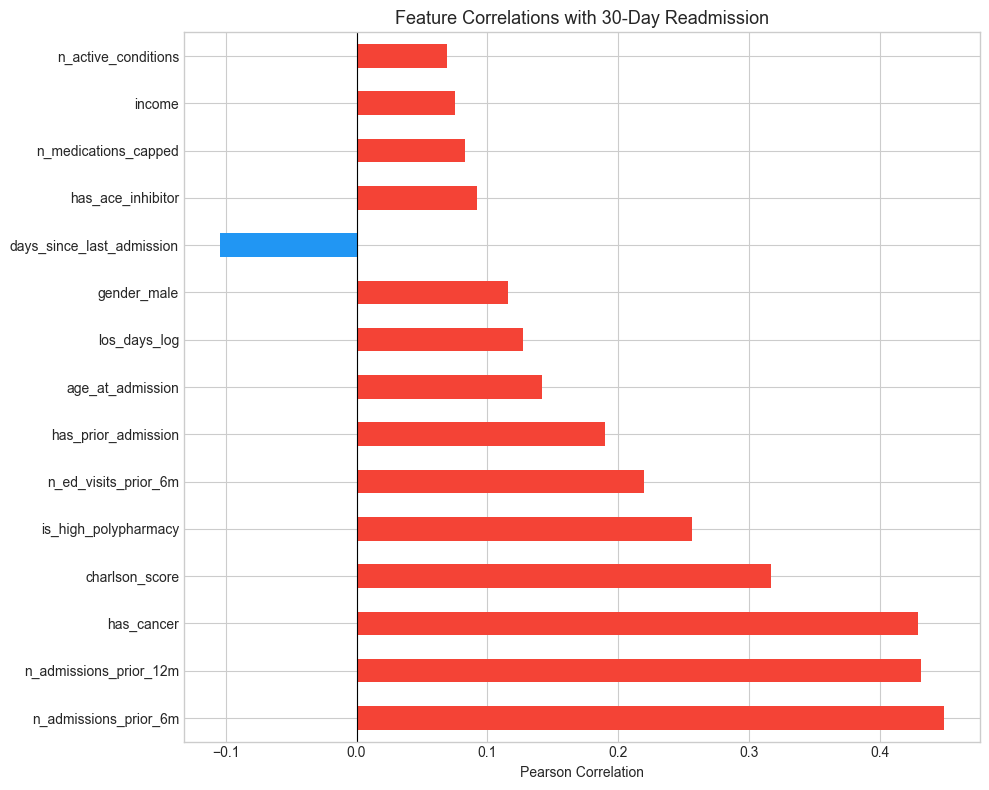

In [9]:
# Feature correlation analysis
# Check which features correlate most with readmission
# This gives us early signal about feature importance

correlations = (
    feature_matrix[FEATURE_COLS + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)

print("=== FEATURE CORRELATIONS WITH READMISSION ===")
print("\nTop 15 features by correlation strength:")
print(correlations.head(15).round(3))

# Visualise
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#F44336' if x > 0 else '#2196F3'
          for x in correlations.head(15).values]
correlations.head(15).plot(
    kind='barh', ax=ax, color=colors
)
ax.set_title('Feature Correlations with 30-Day Readmission',
             fontsize=13)
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(
    '../reports/figures/02_feature_correlations.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

In [10]:
# Save feature matrix

output_path = f"{PROCESSED_PATH}/feature_matrix.csv"
feature_matrix.to_csv(output_path, index=False)

print("=== FEATURE MATRIX SAVED ===")
print(f"\nFile: {output_path}")
print(f"Shape: {feature_matrix.shape}")
print(f"Readmission rate: "
      f"{feature_matrix[TARGET_COL].mean()*100:.1f}%")

=== FEATURE MATRIX SAVED ===

File: ../data/processed/feature_matrix.csv
Shape: (3680, 34)
Readmission rate: 8.7%


---

## Summary

| Metric | Value |
|--------|-------|
| Source data | Synthea 11,381 patients |
| Raw inpatient encounters | 6,198 |
| After exclusions + adult filter | 3,680 |
| Paediatric encounters removed | 93 |
| Positive cases (readmitted) | 321 (8.7%) |
| Unique patients | ~2,944 |
| Features engineered | 31 |
| Feature sources | 4 tables |
| Missing values | None |
| Output file | `data/processed/feature_matrix.csv` |
| Final matrix shape | (3,680 × 34) |

---

## Top 15 Features by Correlation with Readmission

| Rank | Feature | Correlation | Clinical interpretation |
|------|---------|:-----------:|------------------------|
| 1 | n_admissions_prior_6m | +0.449 | Strongest predictor — unstable disease pattern |
| 2 | n_admissions_prior_12m | +0.431 | 12-month history adds independent signal |
| 3 | has_cancer | +0.429 | Cancer patients cycle through admissions frequently |
| 4 | charlson_score | +0.317 | Higher comorbidity burden = higher risk |
| 5 | is_high_polypharmacy | +0.257 | >10 medications signals complex, unstable disease |
| 6 | n_ed_visits_prior_6m | +0.220 | E in LACE — ED utilisation as instability marker |
| 7 | has_prior_admission | +0.190 | Binary: any prior history vs none |
| 8 | age_at_admission | +0.142 | Older patients readmit more — confirmed |
| 9 | los_days_log | +0.127 | L in LACE — longer stay = sicker patient |
| 10 | gender_male | +0.116 | Males readmit at 2× female rate |
| 11 | days_since_last_admission | −0.104 | Negative: longer gap = more stable |
| 12 | has_ace_inhibitor | +0.092 | Cardiovascular complexity marker |
| 13 | n_medications_capped | +0.083 | Polypharmacy — continuous signal |
| 14 | income | +0.076 | Lower income = fewer post-discharge resources |
| 15 | n_active_conditions | +0.069 | Total disease burden |

---

## Clinical Interpretation

**Confirmed by data:**
Prior admission history is the single strongest predictor of
readmission — the top 2 features and feature #7 all capture
the same signal at different granularities (6-month count,
12-month count, binary flag). This is consistent with every
major published readmission study and validates our feature
engineering approach.

All four LACE index components appear in the top 10:
- **L** — los_days_log (rank 9)
- **A** — is_emergency (captured, moderate signal)
- **C** — charlson_score (rank 4)
- **E** — n_ed_visits_prior_6m (rank 6)

**Notable finding:**
`is_high_polypharmacy` (rank 5, r=0.257) outperforms
`n_medications_capped` (rank 13, r=0.083) — suggesting
the binary threshold of >10 medications captures the
clinical risk signal better than the raw count. Patients
crossing the polypharmacy threshold have categorically
higher readmission risk, not just marginally higher.

**Surprise to monitor:**
`has_cancer` ranks 3rd (r=0.429) — nearly as strong as
prior admissions. This likely reflects Synthea's simulation
of chemotherapy cycles rather than true oncology readmission
risk. We will monitor SHAP values in our model training to confirm
whether this represents real signal or a synthetic data
artefact. If cancer dominates model decisions disproportionately,
it will be flagged in the model card.

---

## Data Quality Issues Documented

| Issue | Observed | Impact | Mitigation |
|-------|---------|--------|-----------|
| Medication count inflated | Max 1,217 (lifetime prescriptions) | Overstates polypharmacy | Capped at 99th percentile (520) |
| 6 Charlson conditions at 0% | Dementia, PVD, hemiplegia, liver disease, connective tissue, diabetes complications | Underestimates comorbidity in some patients | Keyword matching limitation — noted in model card. ICD codes would be used in production |
| Cancer prevalence elevated | 19.1% vs ~5% real-world | May inflate model's cancer signal | Monitor SHAP values — flag if disproportionate |
| Paediatric patients | 93 encounters (age < 18) | Wrong clinical population for this model | Filtered out — adult-only cohort |
| Timezone mismatch | Synthea exports UTC timestamps | Prevented date comparisons | Stripped at ingestion via `tz_localize(None)` |

---

## Engineering Decisions Made

| Decision | Rationale |
|---------|-----------|
| Log-transform LOS | Right-skewed (max 73 days) — log1p normalises for linear models |
| Temporal integrity | All features use data available strictly before admission date |
| Charlson keyword matching | Pragmatic for Synthea text — production would use SNOMED/ICD codes |
| Sentinel value 999 for days_since_last_admission | First-ever admissions have no prior history — large value signals this cleanly |
| Encounter cap at 6 per patient | Prevents chronic disease patients dominating dataset |
| Medication cap at 99th percentile (520) | Reduces lifetime prescription inflation artefact |
| Adult-only filter (age ≥ 18) | Paediatric readmission is a separate clinical problem |

---

## Next: Model Training

With a validated 31-feature matrix we will train:

1. **Logistic Regression** — interpretable clinical baseline
2. **XGBoost** — production model

Evaluated with AUC-ROC, precision-recall, and Brier score.
SMOTE applied to training data only to handle 8.7% class imbalance.
SHAP explainability generated for global and individual predictions.
Fairness evaluated stratified by age group and gender.

**Expected benchmark:** AUC-ROC > 0.75 to justify clinical deployment.